## Data Cleaning Markdown
- Collect data from Hugging Face
- Subset for variables of interest
- Plot the variables of interest in different ways
- Inspect the data
- Check for NAs
- Clean

### PHASE 1: Data Cleaning

In [176]:
# Setup
from datasets import load_dataset
import numpy as np
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load data set for only the food products
ds = load_dataset("openfoodfacts/product-database", split="food")

Generating food split: 4398832 examples [01:34, 46537.23 examples/s] 
Generating beauty split: 57986 examples [00:02, 25891.87 examples/s]


In [7]:
# columns of interest
columns_of_interest = [
    "product_name",
    "brands",
    "nova_group",
    "nutriscore_score",
    "nutriscore_grade",
    "lang",
    "ingredients_original_tags",
    "code"
]

# convert to df
df = ds.select_columns(columns_of_interest).to_pandas()

In [ ]:
# create data directory if it doesn't exist
if not os.path.exists("../data"):
    os.makedirs("../data")
df.to_csv("../data/raw_data.csv", index=False)

In [13]:
# Inspect first few rows of the dataset
df.head()

,product_name,brands,nova_group,nutriscore_score,nutriscore_grade,lang,ingredients_original_tags,code
0,"[{'lang': 'main', 'text': 'Véritable pâte à ta...",Bovetti,NaN,25.0,e,fr,None,0000101209159
1,"[{'lang': 'main', 'text': 'Chamomile Herbal Te...",Lagg's,1.0,NaN,unknown,en,[en:camomile-flower],0000105000011
2,"[{'lang': 'main', 'text': 'Lagg's, herbal tea,...",Lagg's,1.0,NaN,unknown,en,[en:peppermint],0000105000042
3,"[{'lang': 'main', 'text': 'Linden Flowers Tea'...",Lagg's,NaN,NaN,unknown,en,[en:linden-flowers],0000105000059
4,"[{'lang': 'main', 'text': 'Herbal Tea, Hibiscu...",Lagg's,NaN,NaN,unknown,en,[en:roselle-flower],0000105000073


In [14]:
# See rows and columns
df.shape

(4398832, 8)

In [15]:
# filter for only rows where lang is 'en'
df = df[df["lang"] == "en"]

df.shape

(1827474, 8)

In [ ]:
# Extract product name from product name dictionary column
df['product_name_clean'] = df['product_name'].apply(
    lambda x: x[0]['text'] if isinstance(x, np.ndarray) and len(x) > 0 else None
)

# see list of all product names
df_filtered["product_name_clean"].head(20)

['Soft baked mini cookies', 'Cadbury mini eggs chocolate eggs mini', 'Chopped Raw Walnuts', 'Cadbury mini eggs chocolate eggs mini', 'Cheesy Spinach Potatoes au Gratin']


In [58]:
# concatenate brand and product name to create a unique product ID - if brand is na then just use product name
df["product_ID"] = np.where(
    df["brands"].isna(),
    df["product_name_clean"].astype(str),
    df["brands"] + "_" + df["product_name_clean"].astype(str)
)

# make sure no products duplicated by "code" (barcode) - also unique product ID
if df["code"].nunique() != len(df):
    print("Warning: code column has duplicates.")

# for code duplicates keep the instance with the most data (least missing values)
df["missing_values"] = df.isna().sum(axis=1)
df = df.sort_values("missing_values").drop_duplicates(subset="code", keep="first").drop(columns="missing_values")

# double check for duplicates after dropping
if df["code"].nunique() != len(df):
    print("Warning: code column has duplicates.")
else:
    print("No duplicates in code column.")

No duplicates in code column.


In [62]:
df.shape

(1827468, 10)

### PHASE 2: Data Inspection & Plotting

In [166]:
# count na in each column
na_count = df.isna().sum()

# get percentage of missing values in each column
na_percent = df.isna().mean()*100

# combine into a dataframe
na_df = pd.DataFrame({"na_count": na_count, "na_percent": na_percent})
print(na_df)

                           na_count  na_percent
product_name                      0    0.000000
brands                       622872   34.083880
nova_group                  1302153   71.254490
nutriscore_score            1315441   71.981616
nutriscore_grade              37340    2.043264
lang                              0    0.000000
ingredients_original_tags   1203861   65.875900
code                              0    0.000000
product_name_clean           165925    9.079502
product_ID                   165925    9.079502


OBS: We have quite a lot of data without a nova group or a numerical nutriscore score. But many more do have a nutrigrade. So we should probably use the grade instead of the score - I will continue by using the nutrigrade.

Quite a lot of the data also does not have ingredients original tags - perhaps we need to check how much we have and if we use a different column from the OG data.

#### Create filtered df where there are ingredients and nutriscores

In [167]:
# filter for rows with a nutriscore_grade and ingredients_original_tags
df_filtered = df[df["nutriscore_grade"].notna() & df["ingredients_original_tags"].notna()]

df_filtered.shape

(623594, 10)

#### Inspect df with novas for NA inspection

In [168]:
# create df where nova is present
with_nova = df_filtered[df_filtered["nova_group"].notna()].copy()

with_nova.shape

(516374, 10)

In [169]:
# see how many products fall into each nova score for the with nova df
print(with_nova["nova_group"].value_counts())

nova_group
4.0    368966
3.0     87879
1.0     51227
2.0      8302
Name: count, dtype: int64


In [170]:
# see how many products fall into each nutriscore grade for the missing nova df
print(with_nova["nutriscore_grade"].value_counts())

nutriscore_grade
e                 121744
unknown           115706
d                  94465
c                  76251
a                  57771
b                  38137
not-applicable     12300
Name: count, dtype: int64


In [171]:
# exclude all rows with nutriscore_grade == "unknown" and "not-applicable" from the df_filtered data frame
df_filtered = df_filtered[~df_filtered['nutriscore_grade'].isin(['unknown', 'not-applicable'])]

#Checking if they're gone
print(df_filtered["nutriscore_grade"].value_counts())

nutriscore_grade
e    138479
d    102303
c     85741
a     65791
b     49146
Name: count, dtype: int64


#### Inspect df without novas

In [172]:
# see how many rows of the filtered dataset have a nova group
missing_nova = df_filtered[df_filtered["nova_group"].isna()].copy()

missing_nova.shape

(53092, 10)

In [173]:
# percentage of df_filtered that doesn't have a nova
percent_missing_nova = (missing_nova.shape[0] / df_filtered.shape[0]) * 100
print(f"Percentage of df_filtered without nova_group: {percent_missing_nova:.2f}%")

Percentage of df_filtered without nova_group: 12.03%


In [174]:
# see how many products fall into each nutriscore grade for the missing nova df
print(missing_nova["nutriscore_grade"].value_counts())

nutriscore_grade
e    16735
b    11009
c     9490
a     8020
d     7838
Name: count, dtype: int64


Issues to be addressed?
- For the nutriscore grade there is some called unknown and not-applicable -> need to see what we want to do with these? Filter out? or see what the use cases are?
    - not-applicable can be caused by various reasons, mainly:
        
        Alcoholic Beverages: Typically excluded from Nutri-Score calculation.
        
        Single-Ingredient Products: Foods like coffee, tea, herbal infusions, salt, vinegar, and yeast do not receive a grade because they are generally used in small quantities and contain negligible nutrients per serving. 
        
        Unprocessed Products: Raw products like fresh meat, fruit, or vegetables that are sold without additional ingredients often lack a label.
        
        Voluntary Participation: While adopted in several EU countries, Nutri-Score is voluntary, not mandatory. Companies may choose not to use it, leaving products unlabeled.
        
        Specialized Foods: Foods intended for particular nutritional uses (e.g., infant formula) are often exempt.
        
        Missing Information: Products with incomplete nutritional data in the database cannot be graded.

    MEANING: We should delete these, as they both may represent ultra-processed foods, very raw products, missing data AND products where it's simply not applicable. 
- There are varying amount in each nova group (when we split the data again it should be equal between all groups in each df? Amount of data could be seen as a weight?)
    - This will automatically be sorted later on within the stratified data splits. It's okay for now:)

In [ ]:
# create output folder
if not os.path.exists("../output"):
    os.makedirs("../output")

FileNotFoundError: [Errno 2] No such file or directory: 'data/nova_group_distribution.png'

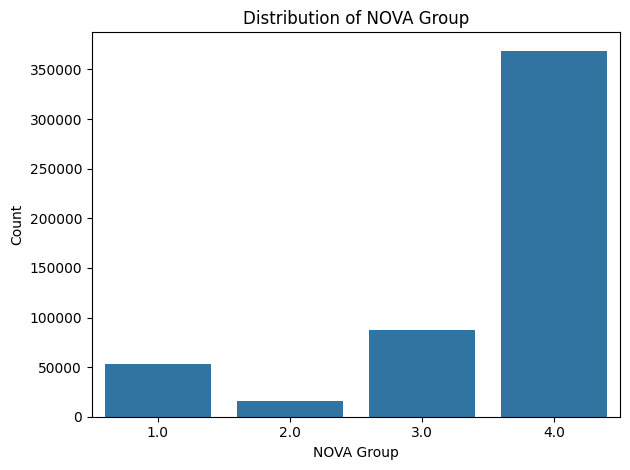

In [ ]:
# Plotting the distribution of nova_group 
sns.countplot(data=df, x='nova_group', order=sorted(df['nova_group'].dropna().unique()))
plt.title('Distribution of NOVA Group')
plt.xlabel('NOVA Group')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../output/nova_group_distribution.png', dpi=150)
plt.show()

In [ ]:
# plotting distribution of nutriscore_score by nova_group
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='nova_group', y='nutriscore_score', 
            order=sorted(df['nova_group'].dropna().unique()),
            palette='RdYlGn_r')
plt.title('Distribution of Nutri-Score by NOVA Group')
plt.xlabel('NOVA Group')
plt.ylabel('Nutri-Score (lower = healthier)')
plt.tight_layout()
plt.savefig('../output/nutriscore_by_nova.png', dpi=150)
plt.show()

notes on the plot above:

- RdYlGn_r is a red-yellow-green reversed palette, which maps nicely since higher nutriscore = less healthy

In [ ]:
# Build the contingency table
heatmap_data = df.groupby(['nova_group', 'nutriscore_grade']).size().unstack(fill_value=0)

# Order the axes meaningfully
nova_order = sorted(heatmap_data.index)
nutriscore_order = ['a', 'b', 'c', 'd', 'e']
heatmap_data = heatmap_data.reindex(index=nova_order, columns=nutriscore_order)

# Normalize by row so each NOVA group sums to 100%
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': '% of NOVA group'})
plt.title('NOVA Group vs Nutri-Score Grade (% within NOVA group)')
plt.xlabel('Nutri-Score Grade (A = healthiest)')
plt.ylabel('NOVA Group (1 = unprocessed, 4 = ultra-processed)')
plt.tight_layout()
plt.savefig('../output/nova_nutriscore_heatmap.png', dpi=150)
plt.show()

notes on plot above: 

- The expected pattern (processing = unhealthy):
NOVA 1 (unprocessed): 55.2% score A — most unprocessed foods are nutritionally good. This makes sense.
NOVA 4 (ultra-processed): 38.8% score E — a big chunk of ultra-processed foods score poorly. Also expected.

- The discordance — this is the interesting part:
NOVA 4 but grade A or B: 7.6% + 7.8% = 15.4% of ultra-processed foods still score well nutritionally. These are things like diet sodas, protein bars, or fortified cereals — heavily processed but engineered to hit good nutrient scores.
NOVA 2 but grade E: 31.7% — this is the biggest surprise. Lightly processed foods scoring very poorly. Think things like salted butter, cured meats, or full-fat cheese — minimally processed but high in fat/salt/sugar.

- The headline takeaway for your write-up:
Nutri-Score and NOVA group measure different things. A food can be ultra-processed yet score A, or barely processed yet score E. The two systems are complementary, not redundant — which is exactly why both matter

In [ ]:
import sys
!{sys.executable} -m pip install missingno
import missingno as msno

plt.figure()
#msno.matrix(df, figsize=(12, 6), fontsize=10, sparkline=False)
msno.bar(df, figsize=(12, 6), fontsize=10)
plt.title('Missing Data Pattern')
plt.tight_layout()
plt.savefig('../output/missing_data_pattern.png', dpi=150)
plt.show()

notes on plot above:

- Bar height = proportion of non-missing values (1.0 = fully complete, 0.0 = all missing)

- The numbers on top = actual count of non-missing rows

### Feature Engineering
#### Ingredient parsing

In [ ]:
# check type of input for ingredients_original_tags
print(df_filtered['ingredients_original_tags'].iloc[0])
print(type(df['ingredients_original_tags'].iloc[0]))

# Check the range of types present in the column
print(df_filtered['ingredients_original_tags'].apply(type).value_counts())

['en:flour-blend' 'en:cane-invert-syrup' 'en:palm-fruit-oil'
 'en:sunflower-oil' 'en:vegetable-glycerin' 'en:baking-powder'
 'en:cinnamon' 'en:vegetable-extract' 'en:sea-salt'
 'en:natural-flavouring' 'en:oat-flour' 'en:tapioca' 'en:chia-seed'
 'en:spinach' 'en:broccoli' 'en:carrot' 'en:tomato' 'en:beetroot'
 'en:shiitake']
<class 'numpy.ndarray'>
ingredients_original_tags
<class 'numpy.ndarray'>    441460
Name: count, dtype: int64


In [ ]:
# E number categories based on EU classification:
emulsifiers = range(400,500) # E400-E499
antioxidants = range(300,400) # E300-E399
preservatives = range(200,300) # E200-E299
colorants = range(100,200) # E100-E199
sweeteners = range(900,1000) # E950-969

In [ ]:
# Extract E numbers integers from ingredient tags
def extract_e_number(tag):
    "Extract integer from tag and return none if not an E number"
    match = re.match(r'en:e(\d+)', tag)
    return int(match.group(1)) if match else None

In [ ]:
# engineer additive features 
def engineer_additive_features(tags):
    " take the list of ingredient tag strings and return dict of additive features"
    e_nums = [n for tag in tags if (n := extract_e_number(tag)) is not None]

    return {
        "additive_count": len(e_nums),
        "has_additive": int(len(e_nums) > 0),
        "emulsifier_count": sum(1 for e in e_nums if e in emulsifiers),
        "antioxidants_count": sum(1 for e in e_nums if e in antioxidants),
        "preservatives_count": sum(1 for e in e_nums if e in preservatives),
        "colorants_count": sum(1 for e in e_nums if e in colorants),
        "sweeteners_count": sum(1 for e in e_nums if e in sweeteners),
    }

# apply and expand into columns
additive_features = df_filtered['ingredients_original_tags'].apply(engineer_additive_features)
df_filtered = pd.concat(
    [df_filtered, pd.DataFrame(additive_features.tolist(), index=df_filtered.index)],
    axis=1
)

In [ ]:
# Remove E numbers from ingredients_original_tags to create a clean ingredient list
def remove_e_numbers(tags):
    """Join tags into a string, stripping E number tags to avoid double-encoding."""
    return ' '.join(
        t.replace('en:', '').replace('-', '_')   # clean for vectoriser vocab
        for t in tags
        if not re.match(r'en:e\d+', t)           # strip E numbers
    )

df_filtered['ingredients_clean'] = df_filtered['ingredients_original_tags'].apply(remove_e_numbers)

df_filtered['ingredients_clean'].head()

2766518    flour_blend cane_invert_syrup palm_fruit_oil s...
3182110    dark_chocolate peanut coconut dried_apricots g...
16098      tomato_puree tomato tomato_juice basil salt so...
16102      filling cheddar broccoli egg half_and_half cor...
16106      fortified_wheat_flour british_pork water palm_...
Name: ingredients_clean, dtype: str

### Data Split
create df_train, df_val, df_test

In [ ]:
# without nova 
missing_nova = df_filtered[df_filtered["nova_group"].isna()]
# with nova
with_nova = df_filtered[df_filtered["nova_group"].notna()]

# split with nova into stratified train, test, validation sets
from sklearn.model_selection import train_test_split

# Step 1: split off test (20%)
df_train_val, df_test = train_test_split(
    with_nova, 
    test_size=0.2, 
    stratify=with_nova['nova_group'], 
    random_state=42
)

# Step 2: split remaining 80% into train (70%) and val (10%)
# 0.125 of 80% = 10% of total
df_train, df_val = train_test_split(
    df_train_val, 
    test_size=0.125, 
    stratify=df_train_val['nova_group'], 
    random_state=42
)

print(f"Train: {len(df_train)} ({len(df_train)/len(with_nova):.0%})")
print(f"Val:   {len(df_val)} ({len(df_val)/len(with_nova):.0%})")
print(f"Test:  {len(df_test)} ({len(df_test)/len(with_nova):.0%})")

Train: 271857 (70%)
Val:   38837 (10%)
Test:  77674 (20%)


In [ ]:
# Check stratification by nova group
print(df_train["nova_group"].value_counts())
print(df_test["nova_group"].value_counts())
print(df_val["nova_group"].value_counts())

nova_group
4.0    181947
3.0     54710
1.0     30431
2.0      4769
Name: count, dtype: int64
nova_group
4.0    51985
3.0    15632
1.0     8694
2.0     1363
Name: count, dtype: int64
nova_group
4.0    25993
3.0     7816
1.0     4347
2.0      681
Name: count, dtype: int64


The imbalance across the groups is preserved across all the splits which is good. Means they all reflect the same.

### Feature Extraction

In [ ]:
# INGREDIENTS TAGS

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=500,
    min_df=20,        # ignore tags in fewer than 50 products
    binary=False,     # TF-IDF weights (down-weights en:salt etc.)
)

# Fit on training data
X_sparse_train = vectorizer.fit_transform(df_train['ingredients_clean'])

# Transform validation and test data using the same vectorizer
X_sparse_val   = vectorizer.transform(df_val['ingredients_clean'])
X_sparse_test  = vectorizer.transform(df_test['ingredients_clean'])

In [ ]:
# NUTRIGRADE ENCODING TO NUMBERS
# encode nutriscore_grade as ordinal (a=0, b=1, c=2, d=3, e=4
from sklearn.preprocessing import OrdinalEncoder
import scipy.sparse as sp

grade_encoder = OrdinalEncoder(
    categories = [['a', 'b', 'c', 'd', 'e']]
)

def encode_grade(df_split):
    return grade_encoder.transform(df_split[['nutriscore_grade']])

# fit on training data
grade_encoder.fit(df_train[['nutriscore_grade']])

,categories,"[['a', 'b', ...]]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [ ]:
# ADDITIVE FEATURES
additive_cols = [
    "additive_count",
    "has_additive",
    "emulsifier_count",
    "antioxidants_count",
    "preservatives_count",
    "colorants_count",
    "sweeteners_count"
]

In [ ]:
# BUILD MATRIX
# obs: sparse_matrix in build_X is the TF-IDF output.
def build_feature_matrix(df_split, sparse_matrix):
    # encode grade
    grade_encoded = encode_grade(df_split)
    
    # extract additive features
    additive_features = df_split[additive_cols].fillna(0).values
    
    # combine sparse matrix with additive features
    return sp.hstack([grade_encoded, additive_features, sparse_matrix])

# apply function
X_train = build_feature_matrix(df_train, X_sparse_train) # X_spare_train is the TF-IDF output for the training set
X_val   = build_feature_matrix(df_val,   X_sparse_val)
X_test  = build_feature_matrix(df_test,  X_sparse_test)


print(f"X_train shape: {X_train.shape}")  # expect (n, 508) — 1 + 7 + 500

X_train shape: (271857, 508)


In [ ]:
print(f"Grade:     1")
print(f"Additives: {len(additive_cols)}")
print(f"TF-IDF:    {X_sparse_train.shape[1]}")
print(f"Total:     {1 + len(additive_cols) + X_sparse_train.shape[1]}")

Grade:     1
Additives: 7
TF-IDF:    500
Total:     508
